In [ ]:

# ═══════════════════════════════════════════════════════════════
# CELL 1 — Mount Drive
# ═══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, json, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage

PATH_A  = '/content/drive/MyDrive/danew/children-emotions/NewArts2/NewArts2'
PATH_B  = '/content/drive/MyDrive/danew/children-emotions/data'
MERGED  = '/content/merged_dataset'
CLASSES = ['Angry', 'Fear', 'Happy', 'Sad']
MODEL_SAVE = '/content/drive/MyDrive/danew/drawing_emotion_modelfinal.keras'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# ═══════════════════════════════════════════════════════════════
# CELL 2 s— Merge both folders
# ═══════════════════════════════════════════════════════════════
if os.path.exists(MERGED):
    shutil.rmtree(MERGED)
for cls in CLASSES:
    os.makedirs(f'{MERGED}/{cls}', exist_ok=True)

def copy_images(src_root, tag):
    total = 0
    for cls in CLASSES:
        src   = os.path.join(src_root, cls)
        if not os.path.exists(src): continue
        files = [f for f in os.listdir(src)
                 if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))]
        for f in files:
            shutil.copy2(os.path.join(src, f),
                         os.path.join(MERGED, cls, f"{tag}_{f}"))
        total += len(files)
        print(f"  {cls}: {len(files)} from {tag}")
    return total

n1 = copy_images(PATH_A, 'A')
n2 = copy_images(PATH_B, 'B')
print(f"\n✅ Total merged: {n1+n2}")
for cls in CLASSES:
    print(f"  {cls}: {len(os.listdir(f'{MERGED}/{cls}'))}")


  Angry: 100 from A
  Fear: 101 from A
  Happy: 100 from A
  Sad: 106 from A
  Angry: 172 from B
  Fear: 182 from B
  Happy: 167 from B
  Sad: 181 from B

✅ Total merged: 1109
  Angry: 272
  Fear: 283
  Happy: 267
  Sad: 287


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Imports
# ═══════════════════════════════════════════════════════════════
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

print(f"TF: {tf.__version__} | GPU: {tf.config.list_physical_devices('GPU')}")

IMG_SIZE   = 224
BATCH_SIZE = 32
SEED       = 42


TF: 2.19.0 | GPU: []


In [ ]:

# ═══════════════════════════════════════════════════════════════
# CELL 4 — Data generators
# ═══════════════════════════════════════════════════════════════
train_cfg = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.12,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.70, 1.30],
    channel_shift_range=20.0,
    fill_mode='nearest',
)
val_cfg = ImageDataGenerator(rescale=1./255, validation_split=0.20)

train_gen = train_cfg.flow_from_directory(
    MERGED, target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training',
    seed=SEED, classes=CLASSES, shuffle=True,
)
val_gen = val_cfg.flow_from_directory(
    MERGED, target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation',
    seed=SEED, classes=CLASSES, shuffle=False,
)

print(f"Train: {train_gen.samples} | Val: {val_gen.samples}")

cw_arr = compute_class_weight('balanced',
    classes=np.unique(train_gen.classes), y=train_gen.classes)
class_weights = dict(enumerate(cw_arr))
print(f"Class weights: {class_weights}")


Found 878 images belonging to 4 classes.
Found 217 images belonging to 4 classes.
Train: 878 | Val: 217
Class weights: {0: np.float64(1.0257009345794392), 1: np.float64(0.9887387387387387), 2: np.float64(1.0257009345794392), 3: np.float64(0.9627192982456141)}


In [ ]:

# ═══════════════════════════════════════════════════════════════
# CELL 5 — Build model (NO fine-tuning — base stays frozen)
# ═══════════════════════════════════════════════════════════════
base = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3),
                   include_top=False, weights='imagenet')
base.trainable = False   # LOCKED — no fine-tuning this time

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.50)(x)
x = layers.Dense(256, activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.40)(x)
x = layers.Dense(128, activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(len(CLASSES), activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,083,716 (11.76 MB)

 Trainable params: 823,172 (3.14 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


🚀 Training (single phase, base FROZEN, saving best automatically)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3094 - loss: 1.9480
Epoch 1: val_accuracy improved from -inf to 0.41935, saving model to /content/drive/MyDrive/danew/drawing_emotion_modelfinal.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.3102 - loss: 1.9433 - val_accuracy: 0.4194 - val_loss: 1.3532 - learning_rate: 5.0000e-04
Epoch 2/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4114 - loss: 1.4533
Epoch 2: val_accuracy improved from 0.41935 to 0.47005, saving model to /content/drive/MyDrive/danew/drawing_emotion_modelfinal.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.4114 - loss: 1.4537 - val_accuracy: 0.4700 - val_loss: 1.2777 - learning_rate: 5.0000e-04
Epoch 3/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5085 - loss: 1.3046
Epoch 3: val_accuracy improved from 0.47005 to 0.47465, saving model to /content/drive/MyDrive/danew/drawing_emotion_modelfinal.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.5077 - loss: 

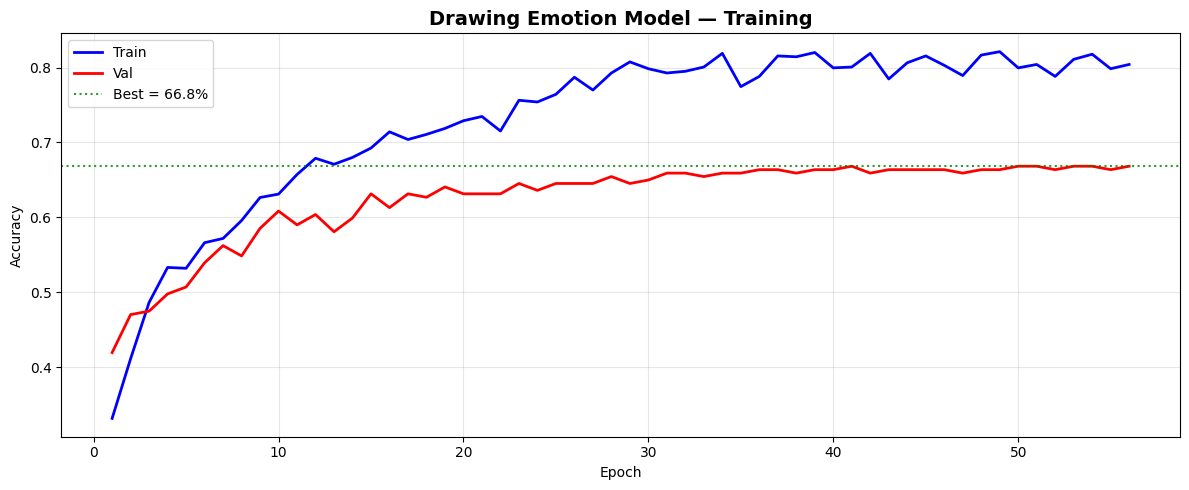

In [ ]:

# ═══════════════════════════════════════════════════════════════
# CELL 7 — Training curve
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
ep = range(1, len(history.history['accuracy'])+1)
ax.plot(ep, history.history['accuracy'],     'b-', lw=2, label='Train')
ax.plot(ep, history.history['val_accuracy'], 'r-', lw=2, label='Val')
ax.axhline(best_acc, color='green', linestyle=':', alpha=0.8,
           label=f'Best = {best_acc:.1%}')
ax.set_title('Drawing Emotion Model — Training', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/training_curve.png', dpi=150)
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step

📊 Report:
              precision    recall  f1-score   support

       Angry       0.67      0.72      0.69        53
        Fear       0.62      0.42      0.50        55
       Happy       0.68      1.00      0.81        53
         Sad       0.69      0.55      0.61        56

    accuracy                           0.67       217
   macro avg       0.66      0.67      0.65       217
weighted avg       0.66      0.67      0.65       217



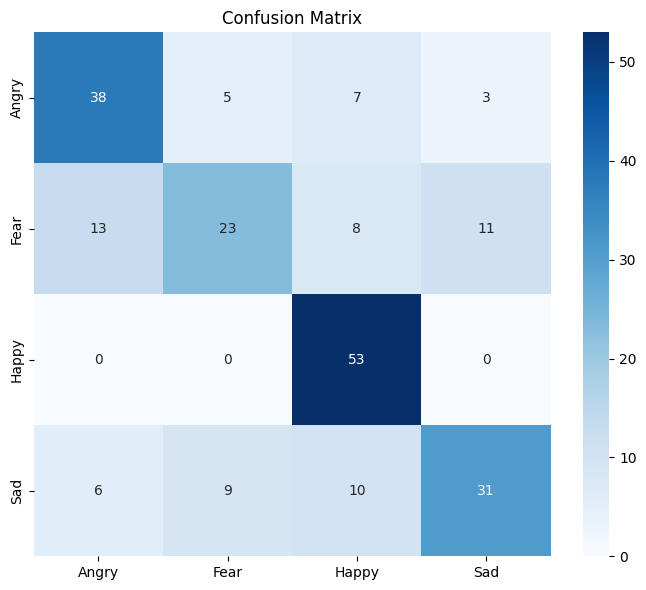


Per-class accuracy:
  Angry   : 71.7%  ██████████████
  Fear    : 41.8%  ████████
  Happy   : 100.0%  ████████████████████
  Sad     : 55.4%  ███████████


In [ ]:

# ═══════════════════════════════════════════════════════════════
# CELL 8 — Evaluate
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_gen.reset()
y_probs = model.predict(val_gen, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)
y_true  = val_gen.classes[:len(y_pred)]

print("\n📊 Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title('Confusion Matrix'); plt.tight_layout()
plt.savefig('/content/confusion.png', dpi=150)
plt.show()

print("\nPer-class accuracy:")
for i, cls in enumerate(CLASSES):
    mask    = y_true == i
    acc_cls = np.mean(y_pred[mask] == i) if mask.sum() > 0 else 0
    bar     = "█" * int(acc_cls * 20)
    print(f"  {cls:8s}: {acc_cls:.1%}  {bar}")


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — Save class map
# ═══════════════════════════════════════════════════════════════
with open('/content/drive/MyDrive/danew/drawing_class_map.json', 'w') as f:
    json.dump({
        'classes':       CLASSES,
        'class_indices': train_gen.class_indices,
        'img_size':      IMG_SIZE,
        'best_accuracy': round(best_acc, 4),
    }, f, indent=2)

print(f"\n{'='*50}")
print(f"🎯 Final accuracy : {best_acc:.1%}")
print(f"📁 Model saved    : {MODEL_SAVE}")
print(f"{'='*50}")
print(f"\n📌 Next steps:")
print(f"  1. Download drawing_emotion_model.keras from Drive")
print(f"  2. Copy to: anxiety-app/backend/model/")
print(f"  3. Restart: uvicorn main:app --reload")



🎯 Final accuracy : 66.8%
📁 Model saved    : /content/drive/MyDrive/danew/drawing_emotion_modelfinal.keras

📌 Next steps:
  1. Download drawing_emotion_model.keras from Drive
  2. Copy to: anxiety-app/backend/model/
  3. Restart: uvicorn main:app --reload
